In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../../_data/01_raw/Membership.csv')

# 성별 N 제거
df_filtered = df[df['gender'] != 'N'].copy()

# 5세 간격 age_bin
bins = np.arange(10, 106, 5) - 0.5
labels = np.arange(10, 101, 5)  # 10, 15, 20, ...
df_filtered['age_bin'] = pd.cut(df_filtered['age'], bins=bins, labels=labels)

# 나이 구간별 전체 수 & 2+4 수
total    = df_filtered.groupby('age_bin', observed=True).size()
multi    = df_filtered[df_filtered['concurrent_streams'].isin([2, 4])].groupby('age_bin', observed=True).size()
ratio    = (multi / total * 100).fillna(0)

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(labels, ratio.reindex(labels, fill_value=0), width=4, color='tomato', alpha=0.8, edgecolor='white')
ax.set_title('Ratio of concurrent_streams 2+4 in Total (by Age, Gender N excluded)')
ax.set_xlabel('Age')
ax.set_ylabel('Ratio (%)')
ax.set_xticks(labels)
ax.tick_params(axis='x', rotation=45)
ax.axhline(ratio.mean(), color='black', linestyle='--', linewidth=1.2,
           label=f'mean={ratio.mean():.1f}%')
ax.legend()

plt.tight_layout()
plt.show()

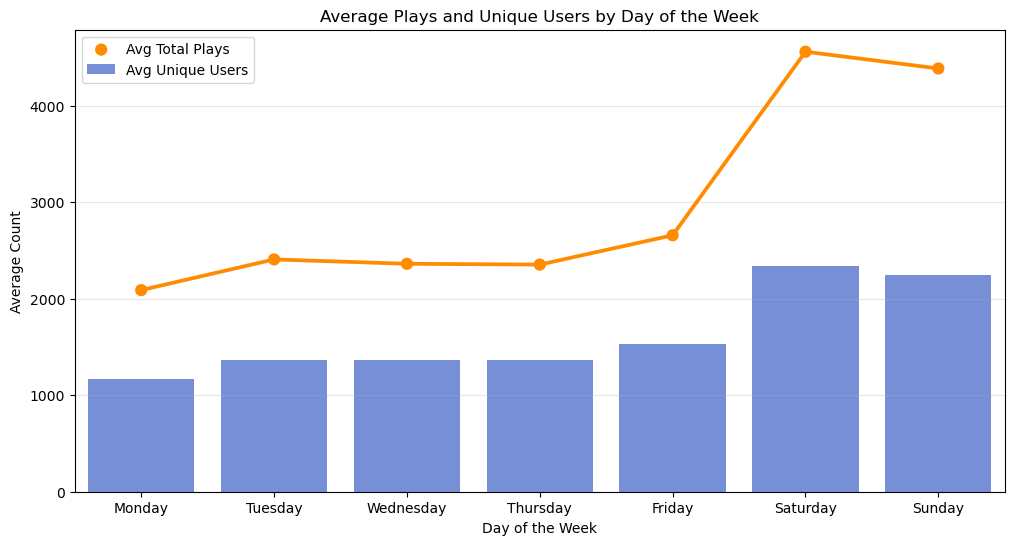

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# 요일별 "평균 고유id 수"와 "평균 시청 수"


df = pd.read_csv("../../_data/01_raw/View_History.csv")
df['WATCH_DAY'] = pd.to_datetime(df['WATCH_DAY'], format='%Y%m%d')

# 요일 정보 추출 및 순서 정렬
# 월요일 ~ 일요일 순서로 정렬
df['day_of_week'] = df['WATCH_DAY'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

daily_stats = df.groupby(['WATCH_DAY', 'day_of_week']).agg({
    'USER_ID': ['count', 'nunique']
}).reset_index()
daily_stats.columns = ['WATCH_DAY', 'day_of_week', 'total_plays', 'unique_users']

# 요일별 평균값 계산
dow_stats = daily_stats.groupby('day_of_week').agg({
    'total_plays': 'mean',
    'unique_users': 'mean'
}).reindex(day_order).reset_index()

# 시각화
plt.figure(figsize=(12, 6))

# 고유 유저 수
sns.barplot(data=dow_stats, x='day_of_week', y='unique_users', color='royalblue', alpha=0.8, label='Avg Unique Users')

# 전체 재생 건수
sns.pointplot(data=dow_stats, x='day_of_week', y='total_plays', color='darkorange', label='Avg Total Plays')

plt.title('Average Plays and Unique Users by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Average Count')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

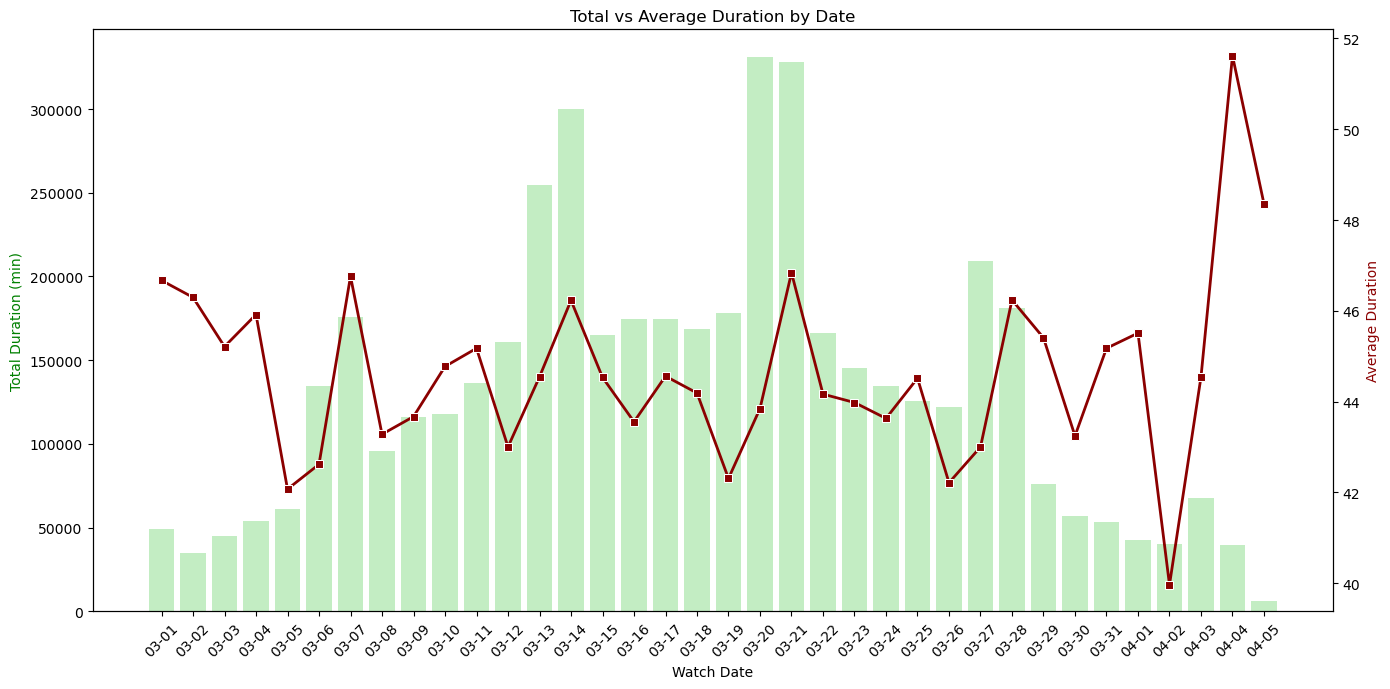

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# 날짜별 "총 duration"과 "평균 duration"


df = pd.read_csv("../../_data/01_raw/View_History.csv")
df['WATCH_DAY'] = pd.to_datetime(df['WATCH_DAY'], format='%Y%m%d')

# 날짜별 시청 시간 집계
duration_stats = df.groupby('WATCH_DAY')['DURATION'].agg(['sum', 'mean']).reset_index()
duration_stats.columns = ['WATCH_DAY', 'total_duration', 'avg_duration']

# 시각화
fig, ax1 = plt.subplots(figsize=(14, 7))

# 총 시청 시간
sns.barplot(data=duration_stats, x='WATCH_DAY', y='total_duration', ax=ax1, color='lightgreen', alpha=0.6)
ax1.set_ylabel('Total Duration (min)', color='green')
ax1.set_xlabel('Watch Date')
ax1.set_title('Total vs Average Duration by Date')

date_labels = duration_stats['WATCH_DAY'].dt.strftime('%m-%d')
ax1.set_xticklabels(date_labels, rotation=45)

# 평균 시청 시간
ax2 = ax1.twinx()
sns.lineplot(data=duration_stats, x=range(len(duration_stats)), y='avg_duration', ax=ax2, color='darkred', marker='s', linewidth=2)
ax2.set_ylabel('Average Duration', color='darkred')

plt.tight_layout()
plt.show()

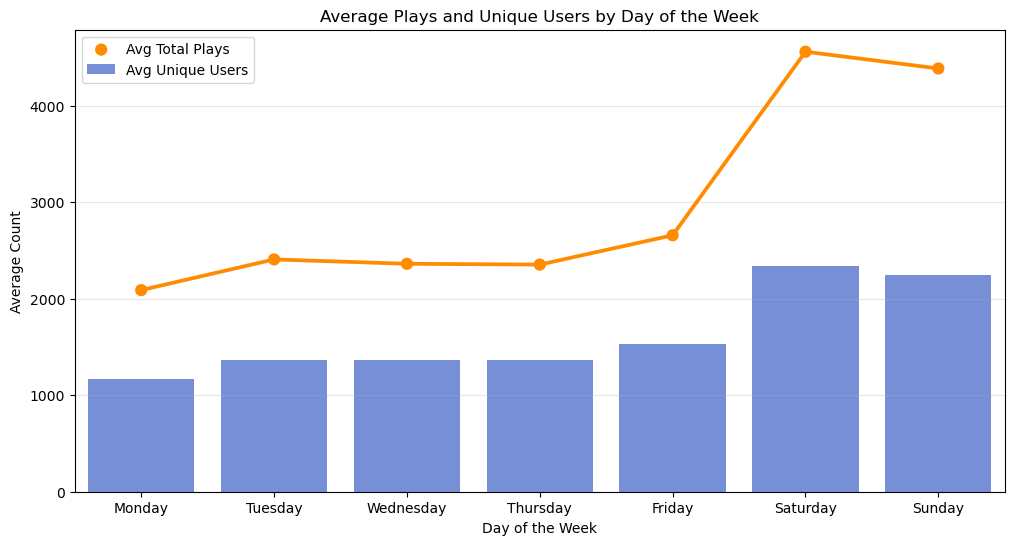

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# 요일별 "총 duration"과 "평균 duration"


df = pd.read_csv("../../_data/01_raw/View_History.csv")
df['WATCH_DAY'] = pd.to_datetime(df['WATCH_DAY'], format='%Y%m%d')

df['day_of_week'] = df['WATCH_DAY'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# 요일별 Duration 집계
dow_duration_stats = df.groupby('day_of_week')['DURATION'].agg(['sum', 'mean']).reindex(day_order).reset_index()
dow_duration_stats.columns = ['day_of_week', 'total_duration', 'avg_duration']

# 시각화
fig, ax1 = plt.subplots(figsize=(12, 6))

# 요일별 총 시청 시간 합계
sns.barplot(data=dow_duration_stats, x='day_of_week', y='total_duration', ax=ax1, color='salmon', alpha=0.7)
ax1.set_ylabel('Total Duration Sum', color='salmon')
ax1.set_xlabel('Day of the Week')
ax1.set_title('Total vs Average Duration by Day of the Week')

# 요일별 평균 시청 시간
ax2 = ax1.twinx()
sns.lineplot(data=dow_duration_stats, x=range(len(dow_duration_stats)), y='avg_duration', ax=ax2, color='darkblue', marker='o', linewidth=2)
ax2.set_ylabel('Average Duration', color='darkblue')

plt.tight_layout()
plt.show()